## Premature Mortality < 65 (Anteil Todesfälle unter 65)
Ziel dieses Abschnitts ist es für jedes Land und jedes Jahr den Anteil der Todesfälle zu berechnen, dievor dem 65. Lbenensjahr aufgetreten sind.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

RuntimeError: CPU dispatcher tracer already initlized

In [ ]:
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv")

### Todesfälle unter 65 berechnen
Für jede einzelne Row summieren wir alle Todesfälle in den Altersklassen 0 bis 64. Da manche Länder pro Jahr mehrere Einträge haben aggregieren wir die Daten nach Country und Year. Für jedes Jahr berechnen wir deaths_u65 und deaths_total. Damit können wir dann p_u65 berechnen. 

In [ ]:
age_u65 = ["Deaths at age 0","Deaths at age 1","Deaths at age 2","Deaths at age 3","Deaths at age 4","Deaths at age 5-9","Deaths at age 10-14","Deaths at age 15-19","Deaths at age 20-24","Deaths at age 25-29","Deaths at age 30-34","Deaths at age 35-39","Deaths at age 40-44","Deaths at age 45-49","Deaths at age 50-54","Deaths at age 55-59","Deaths at age 60-64"]

df["deaths_u65_row"] = df[age_u65].sum(axis=1)

grouped = df.groupby(["Country", "Year"]).agg(deaths_u65_total=("deaths_u65_row", "sum"), deaths_all_total=("Deaths at all ages", "sum"),).reset_index()

grouped["p_u65"] = grouped["deaths_u65_total"] / grouped["deaths_all_total"]


grouped = grouped.dropna(subset=["p_u65"])

print(grouped.head())

    Country  Year  deaths_u65_total  deaths_all_total     p_u65
0  Anguilla  2000              26.0               144  0.180556
1  Anguilla  2001              28.0               104  0.269231
2  Anguilla  2002              42.0               114  0.368421
3  Anguilla  2003              50.0               140  0.357143
4  Anguilla  2004              22.0                96  0.229167


## Analyse des Referenzjahrs 2016
Nachdem wir überprüft habe, in welchen Jahren die meisten Länder Daten lieferten, fokussieren wir und hier auf das Jahr 2016, da diese eine gute Daten Abdeckung hat. Die Analyse des Jahres 2016 dient vor allem dazu ein Verständnis für die Verteilung und weitere Faktoren zu bekommen. 

Wir fokussieren uns hier auf die Verteilugn von p_u65 im Jahr 2016. 
Das Histogramm zeigt, wie häufig verschiedene p-Werte unter den Ländern vorkommen
Die KDE-Kurve gibt eine Schätzung der der Wahrscheinlichkeitsdichte

Wir wollen dabei erkennen, wie die Verteilung ist, ob es Ausreisser gibt und in welchem Bereich sich die meisten Länder bewegen

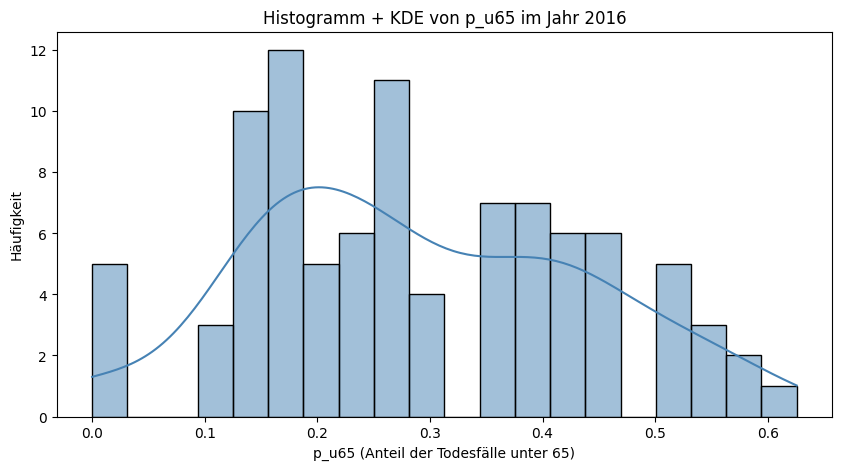

In [ ]:
df_2016 = grouped[grouped["Year"] == 2016].dropna(subset=["p_u65"])

plt.figure(figsize=(10, 5))
sns.histplot(df_2016["p_u65"], bins=20, kde=True, color="steelblue")

plt.title("Histogramm + KDE von p_u65 im Jahr 2016")
plt.xlabel("p_u65 (Anteil der Todesfälle unter 65)")
plt.ylabel("Häufigkeit")
plt.show()

Das Histogramm zeigt eine klare schiefe Verteilung. Die meisten Länder liegen im Bereich 0.15 bis 0.35. Es gibt einen langen rechten Schwanz. Einige Länder haben deutlich höhere p-Werte und daher einen höheren Anteil an Todesfällen unter 65. Es gibt auch einige sehr niedrige Werte. Bei den Werte nahe bei 0, handelt es sich möglicherweise um Datenfehler. 
Die KDE Kurve bestätigt ein Peak um etwa 0.2 und dann gibt es ein langsames abfallen Richtung 0.6

### ECDF von p_u65 im Jahr 2016
Um die Verteilung von p_u65 genauer zu beschreiben, verwenden wir zusätzlich ein ECDF

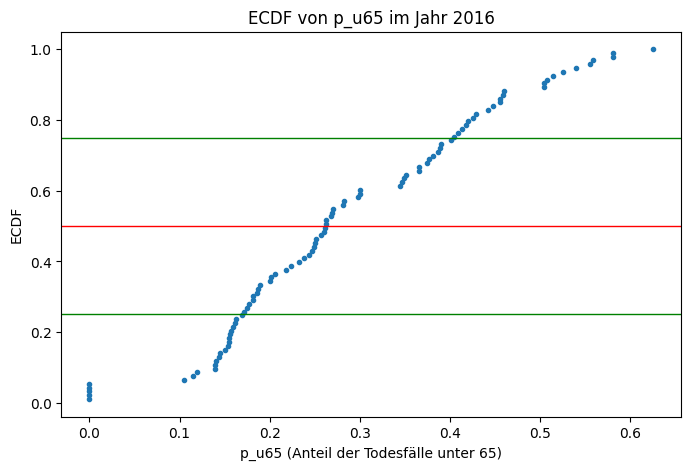

Median: 0.26
Q1: 0.17
Q2: 0.41


In [ ]:
x = np.sort(df_2016["p_u65"])
y = np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, marker=".", linestyle="none")

plt.xlabel("p_u65 (Anteil der Todesfälle unter 65)")
plt.ylabel("ECDF")
plt.title("ECDF von p_u65 im Jahr 2016")

plt.axhline(0.5, color="red", linewidth=1)
plt.axhline(0.25, color="green", linewidth=1)
plt.axhline(0.75, color="green",linewidth=1)
plt.show()

median_2016 = np.median(x)
q1_2016 = np.percentile(x, 25)
q3_2016 = np.percentile(x, 75)

print(f"Median: {median_2016:.2f}")
print(f"Q1: {q1_2016:.2f}")
print(f"Q2: {q3_2016:.2f}")


Die ECDF zeigt die Verteilung des Anteils der Todesfälle unter 65 Jahren über alle Länder im Jahr 2016.
Median: 0.26
Q1: 0.17
Q2: 0.41
Damit liegt die Hälfte der Länder zwischen 17% und 41%

Einige Länder haben einen Wert von 0.0. Diese Werte sind sehr wahrscheinlich Datenprobleme und spiegeln keine realistische Mortalität wieder. Wir werden sie später als Ausreisser markieren und entscheiden ob wir sie löschen.

### Tukey Fences für das Jahr 2016

In [ ]:
q1 = df_2016["p_u65"].quantile(0.25)
q3 = df_2016["p_u65"].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"Q1 = {q1:.3f}, Q3 = {q3:.3f}, IQR = {iqr:.3f}")
print(f"Lower fence = {lower_fence:.3f}, Upper fence = {upper_fence:.3f}")

# Outlier markieren
df_2016["tukey_flag"] = "ok"
df_2016.loc[df_2016["p_u65"] < lower_fence, "tukey_flag"] = "low_outlier"
df_2016.loc[df_2016["p_u65"] > upper_fence, "tukey_flag"] = "high_outlier"

df_y_outliers = df_2016[df_2016["tukey_flag"] != "ok"]
df_y_outliers.sort_values("p_u65").head()

Q1 = 0.171, Q3 = 0.405, IQR = 0.234
Lower fence = -0.180, Upper fence = 0.756


,Country,Year,deaths_u65_total,deaths_all_total,p_u65,tukey_flag


Da alle Werte logisch nur zwischen 0 und 1 liegen, fällt kein Land unter die Untergrenze. Einige Länder liegen jedoch nahe an der Obergrneze, welche 0.75 ist, überschreiten sie aber nicht. Laut Tukey Fences gibt es hier aber keine Ausreisser.

In [ ]:

x = df_2016["p_u65"]

# Tukey-Grenzen hast du ja schon:
# lower_fence, upper_fence

plt.figure(figsize=(10, 4))

# Boxplot
plt.boxplot(x, vert=False)

# Tukey-Grenzen einzeichnen
plt.axvline(lower_fence, linestyle="--", linewidth=2, label="Lower Tukey Fence")
plt.axvline(upper_fence, linestyle="--", linewidth=2, label="Upper Tukey Fence")

# 0-Werte explizit markieren
zero_values = x[x == 0]
y_jitter = np.random.normal(1, 0.02, size=len(zero_values))
plt.scatter(zero_values, y_jitter, label="0-Werte (inhaltlich unsinnig)", zorder=3)

plt.title("p_u65 mit Tukey-Fences und problematischen 0-Werten (2016)")
plt.xlabel("p_u65 (Anteil Todesfälle unter 65)")
plt.legend()
plt.show()


### Löschen der 0-Werte
Ein Wert von 0 ist sehr unlogisch und es handelt sich daher mit Sicherheit um Datenfehler. Aus diesem Grund löschen wir diese aus dem Datensatz

In [ ]:
df_2016 = df_2016[df_2016["p_u65"] > 0].copy()

### Karte 2016
Wir erstellen eine Karte, welche die Anteile der Todesfälle im Jahr 2016 unter 65 zeigt.
Wir sehen, dass viele entwickelte Länder ein kleinerer Anteil der Todesfälle vor dem 65. Geburtstag haben. In Teilen Südamerikas und Zentralasien ist der Anteil deutlich höher. Ausserdem ist aufällig, dass zahlreiche Länder keine Daten meldeten, vor allem Länder in Afrika.

In [ ]:
import plotly.express as px

df_2016_map = df_2016.copy()

fig = px.choropleth(
    df_2016_map,
    locations="Country",
    locationmode="country names",
    color="p_u65",
    color_continuous_scale="Reds",
    range_color=(df_2016_map["p_u65"].min(), df_2016_map["p_u65"].max()),
    title="Anteil Todesfälle unter 65 Jahren im Jahr 2016",
    labels={"p_u65": "Anteil < 65"}
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
)

fig.write_html("karte_p_u65_2016.html")


C:\Users\nevio\AppData\Local\Temp\ipykernel_37032\3325557699.py:6: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.

